In [1]:
import sys
sys.path.append("../")

In [2]:
import torch
import numpy as np
import pandas as pd
import tempfile
import torch.optim as optim
import os
import matplotlib.pyplot as plt

from experiments_rules.PINN_class import DINN
from experiments_rules.loss import *

# Определяем девайс: cuda если есть, иначе cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

torch.manual_seed(123)
if device.type == 'cuda':
    torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.deterministic = True

covid_cases = pd.read_csv('simulation.csv')

S = covid_cases['S']
I = covid_cases['I']
D = covid_cases['D']
R = covid_cases['R']
susceptible = []
infected = []
dead = []
recovered = []
timesteps = []

d1 = covid_cases['S']
d2 = covid_cases['I']
d3 = covid_cases['D']
d4 = covid_cases['R']
# d5 = covid_cases['t']

for item in range(len(d4)):
    if item % 1 == 0:
        susceptible.append(d1[item])
        infected.append(d2[item])
        dead.append(d3[item])
        recovered.append(d4[item])
        timesteps.append(float(item))

x = 101

In [3]:
len(d4)

320

In [12]:
def train(model: DINN, n_epochs):
        # Train
        print('\nStarting training...\n')

        optimizer = optim.Adam(model.params, lr=1e-4)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.1)

        for epoch in range(n_epochs):
            S_pred_list = []
            I_pred_list = []
            D_pred_list = []
            R_pred_list = []
            alpha_pred_list = []

            f1, f2, f3, f4, S_pred, I_pred, D_pred, R_pred, alpha_pred = model.net_f(
                model.t_batch)
            optimizer.zero_grad()

            S_pred_list.append(model.S_min + (model.S_max - model.S_min) * S_pred)
            I_pred_list.append(model.I_min + (model.I_max - model.I_min) * I_pred)
            D_pred_list.append(model.D_min + (model.D_max - model.D_min) * D_pred)
            R_pred_list.append(model.R_min + (model.R_max - model.R_min) * R_pred)
            alpha_pred_list.append(alpha_pred)

            loss_data = data_loss(model.S_hat[:model.train_size], S_pred[:model.train_size], 
                                  model.I_hat[:model.train_size], I_pred[:model.train_size], 
                                  model.D_hat[:model.train_size], D_pred[:model.train_size], 
                                  model.R_hat[:model.train_size], R_pred[:model.train_size], 
                                  weight=1.0)

            loss_ODE = ODE_loss(f1, f2, f3, f4, weight=1.0)

            loss_IBC = initial_boundary_conditions_loss(I_pred[0], I_pred[-1], weight=1.0)

            loss_peak_position = peak_position_loss(I_pred, torch.tensor(200.0))

            loss_peak_height = peak_height_loss(I_pred, torch.tensor(140.0))

            # print(model.train_size)
            loss_slow_growth = slow_growth_penalty(I_pred, model.train_size)

            w1 = 1000.0
            w2 = 1.0
            w3 = 0.5
            w4 = 0.0
            w5 = 2.0
            w6 = 2.0

            loss = w1 * loss_data + w2 * loss_ODE + w3 * loss_IBC + w4 * loss_peak_position + w5 * loss_peak_height + w6 * loss_slow_growth

            loss.backward()
            optimizer.step()
            scheduler.step()

            model.losses.append(loss.item())

            # if epoch % 1000 == 0:
            #     print('\nEpoch ', epoch)

            # Loss + model parameters update
            if epoch % 2000 == 0:
                print("="*50)
                print('Epoch: ', epoch)
                print('Loss is: ', loss)
                print('Loss data: ', loss_data)
                print('Loss ODE: ', loss_ODE)
                print('Loss I_B_C: ', loss_IBC)
                print('Loss peak_position: ', loss_peak_position)
                print('Loss peak_height: ', loss_peak_height)
                print('Loss slow_growth: ', loss_slow_growth)
                print('\ndinn.beta', model.beta)
                print('dinn.gamma', model.gamma)
                print(alpha_pred.shape)

        return S_pred_list, I_pred_list, D_pred_list, R_pred_list, alpha_pred_list

In [13]:
torch.manual_seed(123)
if device.type == 'cuda':
    torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.deterministic = True

dinn = DINN(timesteps, susceptible, infected, dead, recovered, device, x)

In [14]:
S_pred_list, I_pred_list, D_pred_list, R_pred_list, alpha_pred_list =train(dinn, 20001)


Starting training...

DEBUG: peak_index=0, train_size=101
DEBUG: Peak is in training data, returning 0
Epoch:  0
Loss is:  tensor(45128.5214, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
Loss data:  tensor(4.6742, device='cuda:0', dtype=torch.float64, grad_fn=<MulBackward0>)
Loss ODE:  tensor(1335.6407, device='cuda:0', grad_fn=<MulBackward0>)
Loss I_B_C:  tensor(0.0564, device='cuda:0', grad_fn=<MeanBackward0>)
Loss peak_position:  tensor(40000., device='cuda:0')
Loss peak_height:  tensor(19559.3223, device='cuda:0', grad_fn=<PowBackward0>)
Loss slow_growth:  tensor(0., device='cuda:0')

dinn.beta tensor([0.0667], device='cuda:0', grad_fn=<TanhBackward0>)
dinn.gamma tensor([0.5646], device='cuda:0', grad_fn=<TanhBackward0>)
torch.Size([320, 1])
DEBUG: peak_index=0, train_size=101
DEBUG: Peak is in training data, returning 0
DEBUG: peak_index=0, train_size=101
DEBUG: Peak is in training data, returning 0
DEBUG: peak_index=0, train_size=101
DEBUG: Peak is in tra

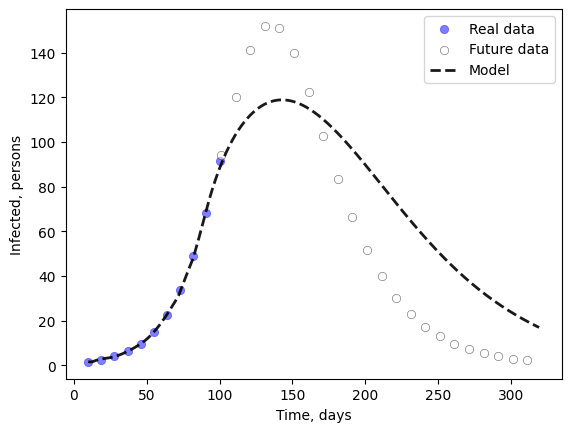

In [15]:
plt.scatter(timesteps[10:x][::9], infected[10:x][::9],
            c='blue', alpha=0.5, lw=0.5, label='Real data')
plt.scatter(timesteps[x:][::10], infected[x:][::10], c='white',
            edgecolors='black', alpha=0.5, lw=0.5, label='Future data')
plt.plot(timesteps[10:], I_pred_list[0].cpu().detach().numpy(
)[10:], 'black', alpha=0.9, lw=2, label='Model', linestyle='dashed')
plt.xlabel("Time, days")
plt.ylabel("Infected, persons")
plt.legend()
plt.show()

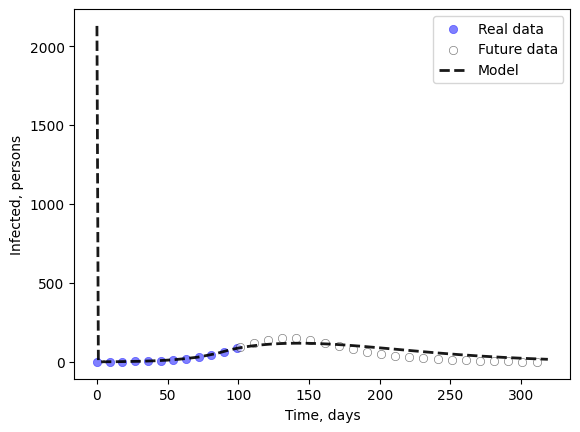

In [16]:
plt.scatter(timesteps[:x][::9], infected[:x][::9],
            c='blue', alpha=0.5, lw=0.5, label='Real data')
plt.scatter(timesteps[x:][::10], infected[x:][::10], c='white',
            edgecolors='black', alpha=0.5, lw=0.5, label='Future data')
plt.plot(timesteps, I_pred_list[0].cpu().detach().numpy(
), 'black', alpha=0.9, lw=2, label='Model', linestyle='dashed')
plt.xlabel("Time, days")
plt.ylabel("Infected, persons")
plt.legend()
plt.show()

In [ ]:
I_pred_list

In [ ]:

def save_model(model, filepath):
    temp_dir = tempfile.gettempdir()
    temp_file_path = os.path.join(temp_dir, filepath)
    """Сохранить модель полностью"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'beta_tilda': model.beta_tilda,
        'gamma_tilda': model.gamma_tilda,
        'S_max': model.S_max,
        'I_max': model.I_max,
        'D_max': model.D_max,
        'R_max': model.R_max,
        'S_min': model.S_min,
        'I_min': model.I_min,
        'D_min': model.D_min,
        'R_min': model.R_min,
        't': model.t,
        'S': model.S,
        'I': model.I,
        'D': model.D,
        'R': model.R,
        'train_size': model.train_size,  # Добавлено
        'device': model.device           # Добавлено
    }, temp_file_path)
    print(f"Model saved to {temp_file_path}")





save_model(dinn, "NEW_MODEL_dinn_cuda_2.pth")